FastVLM in-browser — results analysis

This notebook turns the CSVs you collect (session logs from the app + harness
rows from `bench.js`) into the tables and plots that `docs/03` and `docs/04`
ask for: latency distributions, effective FPS vs drop rate, memory, the
cross-browser / WebGPU-vs-WASM comparison, and an output-quality tally.

**How to use it**
1. Put all your downloaded CSVs in the `data/` folder next to this notebook.
   - Session logs are named like `fastvlm-caption-...csv` (one row per frame).
   - Harness output: paste each `runBenchmark()` CSV line into `data/harness.csv`
     under the header (a template is included).
2. Run all cells (Kernel → Restart & Run All).
3. Figures are saved to `figures/` for dropping straight into your report.

The sample CSVs shipped in `data/` are synthetic, just so the notebook runs
out of the box. Replace them with your real files.

In [1]:
import glob, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "data"
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)
pd.set_option("display.float_format", lambda v: f"{v:,.1f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
print("Files in data/:", sorted(os.path.basename(f) for f in glob.glob(f"{DATA_DIR}/*.csv")))

Files in data/: ['fastvlm-caption-2026-06-08T14-17-58-931Z.csv', 'fastvlm-event-2026-06-08T14-21-00-855Z.csv', 'fastvlm-qa-2026-06-08T14-19-37-223Z.csv', 'harness.csv']


## 1. Load the session logs

Each session-log CSV has a few `#` comment lines at the top (browser, GPU,
drop rate, etc.) followed by the per-frame table. We read the comments as
metadata and the table with `comment='#'`.

In [2]:
def parse_meta(path):
    """Read the leading '# key,value' comment lines into a dict."""
    meta = {"file": os.path.basename(path)}
    with open(path) as f:
        for line in f:
            if not line.startswith("#"):
                break
            body = line[1:].strip()
            if "," in body:
                k, v = body.split(",", 1)
                meta[k.strip()] = v.strip()
    return meta

IGNORE = {"harness.csv", "quality_labels_template.csv"}
session_files = [f for f in glob.glob(f"{DATA_DIR}/*.csv")
                 if os.path.basename(f) not in IGNORE]

frames = []
meta_rows = []
for path in session_files:
    meta = parse_meta(path)
    meta_rows.append(meta)
    df = pd.read_csv(path, comment="#")
    df["file"] = os.path.basename(path)
    frames.append(df)

log = pd.concat(frames, ignore_index=True)
meta_df = pd.DataFrame(meta_rows)
print(f"Loaded {len(session_files)} session logs, {len(log)} total frames.")
meta_df

Loaded 3 session logs, 97 total frames.


,file,generated,userAgent,webgpu,crossOriginIsolated,modelLoadMs,framesProcessed,framesDropped,dropRatePct
0,fastvlm-qa-2026-06-08T14-19-37-223Z.csv,2026-06-08T14:19:37.222Z,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_...",true,true,1916,33,0,0.0
1,fastvlm-event-2026-06-08T14-21-00-855Z.csv,2026-06-08T14:21:00.855Z,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_...",true,true,1916,32,0,0.0
2,fastvlm-caption-2026-06-08T14-17-58-931Z.csv,2026-06-08T14:17:58.925Z,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_...",true,true,1916,32,0,0.0


## 2. Drop the warm-up frame

The first frame of every session (`seq == 0`) includes shader compilation and
is several times slower than steady state. Including it would poison every
latency statistic, so we remove it per file. (The harness already excludes
warm-up on its own.)

In [3]:
before = len(log)
log = log[log["seq"] > 0].copy()
# numeric coercion (ttftMs can be blank if a frame produced no tokens)
for c in ["endToEndMs", "ttftMs", "totalMs", "tokens", "tokensPerSec", "sessionMs"]:
    log[c] = pd.to_numeric(log[c], errors="coerce")
print(f"Dropped {before - len(log)} warm-up rows; {len(log)} frames remain.")
log.head()

Dropped 0 warm-up rows; 97 frames remain.


,seq,sessionMs,mode,source,question,endToEndMs,ttftMs,totalMs,tokens,tokensPerSec,output,file
0,1,1781,qa,file,how many planes are in the frame?,1781,1487,1695,23,110.5,To determine the number of planes in the frame...,fastvlm-qa-2026-06-08T14-19-37-223Z.csv
1,2,3956,qa,file,how many planes are in the frame?,1673,1366,1576,22,105.0,To determine the number of planes in the frame...,fastvlm-qa-2026-06-08T14-19-37-223Z.csv
2,3,6085,qa,file,how many planes are in the frame?,1628,1327,1534,21,101.7,To determine the number of planes in the frame...,fastvlm-qa-2026-06-08T14-19-37-223Z.csv
3,4,8202,qa,file,how many planes are in the frame?,1616,1316,1521,22,107.4,To determine the number of planes in the frame...,fastvlm-qa-2026-06-08T14-19-37-223Z.csv
4,5,10325,qa,file,how many planes are in the frame?,1621,1316,1527,22,104.4,To determine the number of planes in the frame...,fastvlm-qa-2026-06-08T14-19-37-223Z.csv


## 3. Latency by task mode

Median and p95 of the three latency views. `endToEndMs` is what the user feels
(capture→rendered, main thread); `totalMs` is worker-side inference; `ttftMs`
is time to first token. Report all three and explain the gap.

In [4]:
def p95(s):
    return s.quantile(0.95)

latency = (log.groupby("mode")
              .agg(frames=("seq", "count"),
                   med_e2e=("endToEndMs", "median"), p95_e2e=("endToEndMs", p95),
                   med_ttft=("ttftMs", "median"), p95_ttft=("ttftMs", p95),
                   med_total=("totalMs", "median"), p95_total=("totalMs", p95),
                   med_tps=("tokensPerSec", "median"))
              .round(1))
latency

,frames,med_e2e,p95_e2e,med_ttft,p95_ttft,med_total,p95_total,med_tps
mode,,,,,,,,
caption,32,"1,710.0","1,849.3","1,321.5","1,402.2","1,613.5","1,753.3",99.4
event,32,"1,547.0","1,735.9","1,413.5","1,452.4","1,437.5","1,639.4","7,692.3"
qa,33,"1,626.0","1,672.4","1,327.0","1,367.6","1,531.0","1,576.4",102.6


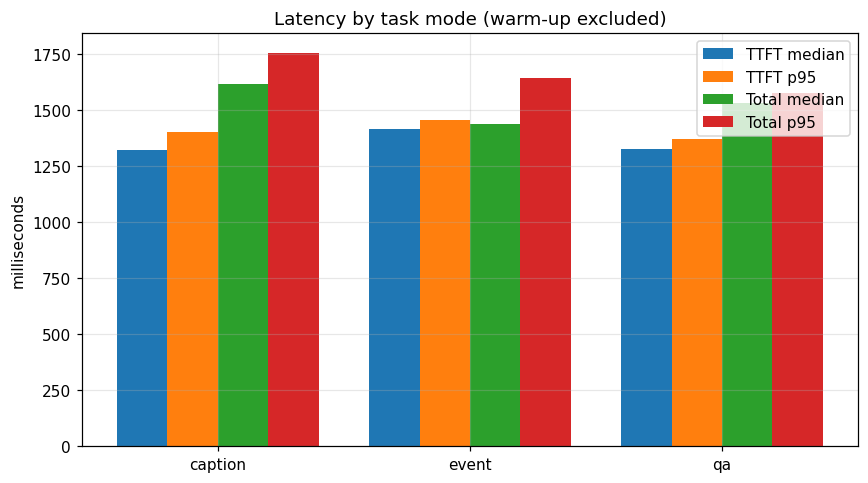

In [5]:
# Plot: median + p95 TTFT and total latency per mode
modes = latency.index.tolist()
x = np.arange(len(modes))
w = 0.2
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - 1.5*w, latency["med_ttft"], w, label="TTFT median")
ax.bar(x - 0.5*w, latency["p95_ttft"], w, label="TTFT p95")
ax.bar(x + 0.5*w, latency["med_total"], w, label="Total median")
ax.bar(x + 1.5*w, latency["p95_total"], w, label="Total p95")
ax.set_xticks(x); ax.set_xticklabels(modes)
ax.set_ylabel("milliseconds"); ax.set_title("Latency by task mode (warm-up excluded)")
ax.legend()
fig.tight_layout(); fig.savefig(f"{FIG_DIR}/latency_by_mode.png"); plt.show()

## 4. Latency distribution (where the stutter lives)

Medians hide tail behavior. A histogram of end-to-end latency shows whether
the model is consistent or occasionally janky.

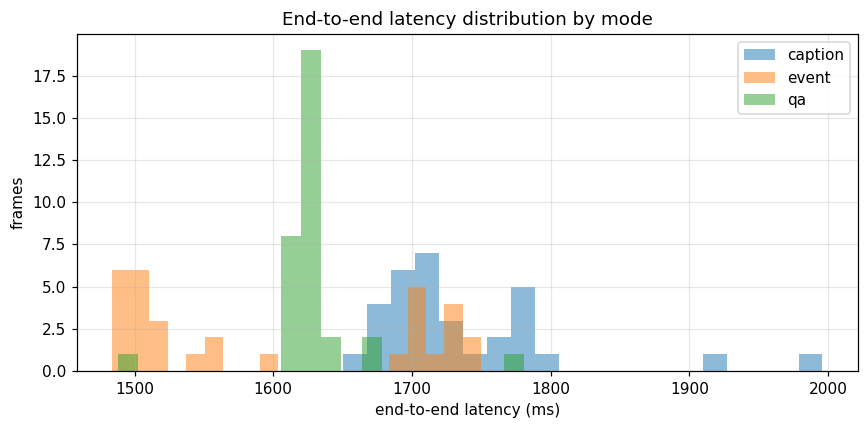

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
for mode, g in log.groupby("mode"):
    ax.hist(g["endToEndMs"].dropna(), bins=20, alpha=0.5, label=mode)
ax.set_xlabel("end-to-end latency (ms)"); ax.set_ylabel("frames")
ax.set_title("End-to-end latency distribution by mode"); ax.legend()
fig.tight_layout(); fig.savefig(f"{FIG_DIR}/latency_hist.png"); plt.show()

## 5. Effective FPS and drop rate

Effective FPS = processed frames ÷ session wall-clock. Drop rate comes from the
`#` metadata each file recorded. If you ran the same video at several sample
intervals, name the files so you can tell them apart (e.g.
`fastvlm-caption-200ms.csv`) and this table will separate them by file.

In [7]:
fps_rows = []
for path in session_files:
    name = os.path.basename(path)
    g = log[log["file"] == name]
    if g.empty:
        continue
    dur_s = (g["sessionMs"].max() - g["sessionMs"].min()) / 1000.0
    eff_fps = len(g) / dur_s if dur_s > 0 else np.nan
    meta = next((m for m in meta_rows if m["file"] == name), {})
    fps_rows.append({
        "file": name,
        "mode": g["mode"].iloc[0],
        "frames": len(g),
        "duration_s": round(dur_s, 1),
        "effective_fps": round(eff_fps, 2),
        "drop_rate_pct": float(meta.get("dropRatePct", "nan")),
    })
fps = pd.DataFrame(fps_rows)
fps

,file,mode,frames,duration_s,effective_fps,drop_rate_pct
0,fastvlm-qa-2026-06-08T14-19-37-223Z.csv,qa,33,68.0,0.5,0.0
1,fastvlm-event-2026-06-08T14-21-00-855Z.csv,event,32,67.1,0.5,0.0
2,fastvlm-caption-2026-06-08T14-17-58-931Z.csv,caption,32,69.4,0.5,0.0


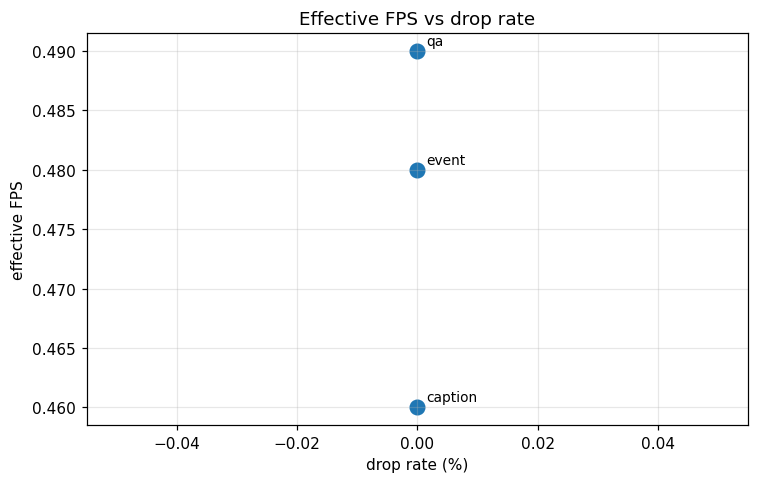

In [8]:
# Plot: effective FPS vs drop rate (the classic trade-off curve).
# Most informative when each point is the same video at a different interval.
if len(fps) >= 1:
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.scatter(fps["drop_rate_pct"], fps["effective_fps"], s=90)
    for _, r in fps.iterrows():
        ax.annotate(r["mode"], (r["drop_rate_pct"], r["effective_fps"]),
                    textcoords="offset points", xytext=(6, 4), fontsize=9)
    ax.set_xlabel("drop rate (%)"); ax.set_ylabel("effective FPS")
    ax.set_title("Effective FPS vs drop rate")
    fig.tight_layout(); fig.savefig(f"{FIG_DIR}/fps_vs_drop.png"); plt.show()

## 6. Harness results — latency, memory, cross-browser, WebGPU vs WASM

`data/harness.csv` holds one row per `runBenchmark()` run. Add a `label` column
describing each run (browser + config) so the charts are readable. The
WebGPU-vs-WASM gap is usually your headline number.

In [9]:
harness = pd.read_csv(f"{DATA_DIR}/harness.csv")
harness

,userAgent,webgpu,crossOriginIsolated,prompt,maxTokens,loadMs,medianTtft,p95Ttft,medianTotal,p95Total,medianTokensPerSec,memBaselineMB,memLoadedMB,memSteadyMB,label
0,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,True,True,<image>Describe this image in one sentence.,32,2094,29740,33901,47615,52821,2,1984,3566,8,NaN


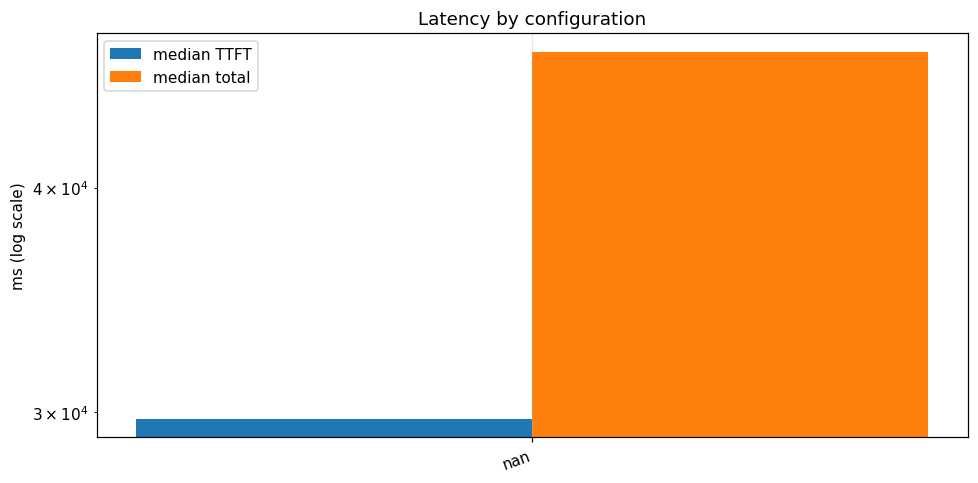

In [10]:
# Median TTFT and total per configuration (log scale — WASM dwarfs WebGPU)
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(harness)); w = 0.35
ax.bar(x - w/2, harness["medianTtft"], w, label="median TTFT")
ax.bar(x + w/2, harness["medianTotal"], w, label="median total")
ax.set_yscale("log")
ax.set_xticks(x); ax.set_xticklabels(harness["label"], rotation=20, ha="right")
ax.set_ylabel("ms (log scale)"); ax.set_title("Latency by configuration")
ax.legend()
fig.tight_layout(); fig.savefig(f"{FIG_DIR}/harness_latency.png"); plt.show()

In [11]:
# Headline: WebGPU vs WASM speedup, if both are present
wg = harness[harness["webgpu"] == True]
wa = harness[harness["webgpu"] == False]
if len(wg) and len(wa):
    speedup = wa["medianTotal"].min() / wg["medianTotal"].min()
    print(f"WebGPU is ~{speedup:.1f}x faster than the WASM fallback "
          f"(best total: {wg['medianTotal'].min():.0f} ms vs {wa['medianTotal'].min():.0f} ms).")
else:
    print("Add a WASM-fallback row to harness.csv to compute the speedup.")

Add a WASM-fallback row to harness.csv to compute the speedup.


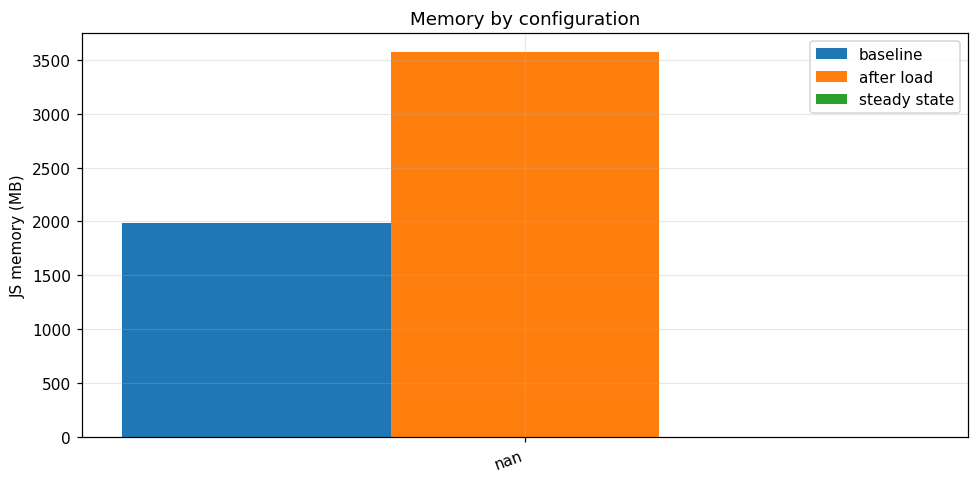

In [12]:
# Memory: baseline vs loaded vs steady, per configuration
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(harness)); w = 0.25
ax.bar(x - w, harness["memBaselineMB"], w, label="baseline")
ax.bar(x, harness["memLoadedMB"], w, label="after load")
ax.bar(x + w, harness["memSteadyMB"], w, label="steady state")
ax.set_xticks(x); ax.set_xticklabels(harness["label"], rotation=20, ha="right")
ax.set_ylabel("JS memory (MB)"); ax.set_title("Memory by configuration")
ax.legend()
fig.tight_layout(); fig.savefig(f"{FIG_DIR}/harness_memory.png"); plt.show()

## 7. Output quality

Latency says nothing about whether the captions were *right*. The session log's
`output` column is your quality signal. There's no automatic ground truth, so
this does two things: surfaces the raw outputs for you to read, and (optionally)
lets you hand-label each row. Fill a `label` of good / vague / wrong in the
exported template, reload, and tally.

In [13]:
# Surface unique outputs per mode for eyeballing
for mode, g in log.groupby("mode"):
    print(f"\n=== {mode} — {len(g)} frames, {g['output'].nunique()} unique outputs ===")
    print(g["output"].value_counts().head(10).to_string())


=== caption — 32 frames, 29 unique outputs ===
output
The image captures a formation of six airplanes flying in a diamond pattern, leaving trails of red and white smoke in the sky, creating a visually striking display.                       2
The image captures a formation of four airplanes flying in a diamond pattern, leaving trails of red and blue smoke against a backdrop of a cloudy sky.                                     2
The image captures a formation of nine fighter jets flying in a V-shape, with the lead jet positioned at the front and the last jet at the back, all set against a backdrop of a cloudy    2
The image captures a vibrant kite soaring high in the sky, its red and blue streamers creating a striking contrast against the backdrop of a cloudy sky.                                   1
The image captures a vibrant kite soaring high in the sky, its long tail streaming behind it, set against a backdrop of a cloudy sky and distant trees.                                    1


In [14]:
# OPTIONAL hand-labeling workflow:
# 1. Run this once to export a template with a blank 'quality' column.
# 2. Open it, fill each row with: good / vague / wrong.
# 3. Re-run the tally cell below.
label_path = f"{DATA_DIR}/quality_labels_template.csv"
if not os.path.exists(label_path):
    log[["file", "seq", "mode", "output"]].assign(quality="").to_csv(label_path, index=False)
    print(f"Wrote {label_path} — fill the 'quality' column, then run the tally cell.")
else:
    print(f"{label_path} already exists.")

Wrote data/quality_labels_template.csv — fill the 'quality' column, then run the tally cell.


In [15]:
# Tally hand-labels if you've filled them in
if os.path.exists(label_path):
    lab = pd.read_csv(label_path)
    lab["quality"] = lab["quality"].astype(str).str.strip().str.lower()
    labeled = lab[lab["quality"].isin(["good", "vague", "wrong"])]
    if len(labeled):
        tally = (labeled.groupby(["mode", "quality"]).size()
                 .unstack(fill_value=0))
        display(tally)
        tally.plot(kind="bar", stacked=True, figsize=(7, 4),
                   title="Output quality by mode (hand-labeled)")
        plt.ylabel("frames"); plt.tight_layout()
        plt.savefig(f"{FIG_DIR}/quality_by_mode.png"); plt.show()
    else:
        print("No labels filled in yet — edit the template's 'quality' column.")

No labels filled in yet — edit the template's 'quality' column.


## 8. Exportable summary

A compact table combining the headline numbers, written to `figures/` as CSV
for your report appendix.

In [16]:
summary = latency.copy()
summary.to_csv(f"{FIG_DIR}/latency_summary.csv")
fps.to_csv(f"{FIG_DIR}/fps_summary.csv", index=False)
print("Wrote figures/latency_summary.csv and figures/fps_summary.csv")
print("\nLatency summary:")
print(summary.to_string())
print("\nFPS summary:")
print(fps.to_string(index=False))

Wrote figures/latency_summary.csv and figures/fps_summary.csv

Latency summary:
         frames  med_e2e  p95_e2e  med_ttft  p95_ttft  med_total  p95_total  med_tps
mode                                                                                
caption      32  1,710.0  1,849.3   1,321.5   1,402.2    1,613.5    1,753.3     99.4
event        32  1,547.0  1,735.9   1,413.5   1,452.4    1,437.5    1,639.4  7,692.3
qa           33  1,626.0  1,672.4   1,327.0   1,367.6    1,531.0    1,576.4    102.6

FPS summary:
                                        file    mode  frames  duration_s  effective_fps  drop_rate_pct
     fastvlm-qa-2026-06-08T14-19-37-223Z.csv      qa      33        68.0            0.5            0.0
  fastvlm-event-2026-06-08T14-21-00-855Z.csv   event      32        67.1            0.5            0.0
fastvlm-caption-2026-06-08T14-17-58-931Z.csv caption      32        69.4            0.5            0.0
